In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Synthetic customer-level RFM data

In [4]:
# We are generating random data, but we want the same random dataset every time we run the practical.
rng = np.random.default_rng(42)

# generating artificial customers with different behavioural patterns.
parts = [(260, 12, 26, 4200), (380, 50, 13, 1800),
         (360, 130, 4, 650), (200, 250, 15, 2400)]

'''(260, 12, 26, 4200)

means approximately:
260 customers
average Recency ≈ 12
average Frequency ≈ 26
average Monetary ≈ 4200 '''


rows = []
for n, recency_mu, frequency_mu, monetary_mu in parts:

    # rng.normal() --> Generates n random numbers from a Normal distribution around a mean.
    # rng.normal(mean, standard_deviation, number_of_values)
    # np.clip(values, lower_limit, upper_limit)    
    recency = np.clip(rng.normal(recency_mu, recency_mu*.20, n), 1, None)

    # Customer purchase frequency is often right-skewed.
    # rng.lognormal(mean, sigma, size) it generates n random values using a log-normal distribution
    frequency = np.clip(rng.lognormal(np.log(frequency_mu), .28, n), 1, None)  
    monetary = np.clip(frequency * rng.lognormal(
        np.log(monetary_mu/frequency_mu), .25, n), 20, None)
    rows.extend(zip(recency, frequency, monetary))
rfm = pd.DataFrame(rows, columns=["Recency", "Frequency", "Monetary"])


In [5]:
rfm

,Recency,Frequency,Monetary
0,12.731321,24.322647,3082.862341
1,9.504038,24.131259,3122.306883
2,13.801083,27.746345,6259.111102
3,14.257355,22.255850,3427.245603
4,7.317516,29.669730,6807.811206
...,...,...,...
1195,302.927641,17.749475,5296.038925
1196,184.911013,11.646014,1674.465343
1197,239.677712,13.945909,1934.445539
1198,301.237837,8.915062,915.234494


# Transform skewed features, then scale them 

Customer data is often skewed:
* Most customers → low/medium values
* Few customers → extremely high values

In [6]:
X = np.log1p(rfm[["Recency", "Frequency", "Monetary"]]) 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 

# Select K using both diagnostics 

In [8]:
ks = range(2, 9) 
inertia, silhouette = [], [] 
models = {} 
for k in ks: 

    # init="k-means++" is used for Better initialization of centroids.
    # Instead of completely random centroid selection, 
    # K-Means++ chooses initial centroids more intelligently.

    # run 20 times with different centroids n_init = 20
    model = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42) 
    labels = model.fit_predict(X_scaled) 
    models[k] = model 

    # Inertia ≈ Total squared distance of customers from their assigned cluster centroid.(WCSS)
    inertia.append(model.inertia_) 

    silhouette.append(silhouette_score(X_scaled, labels)) 

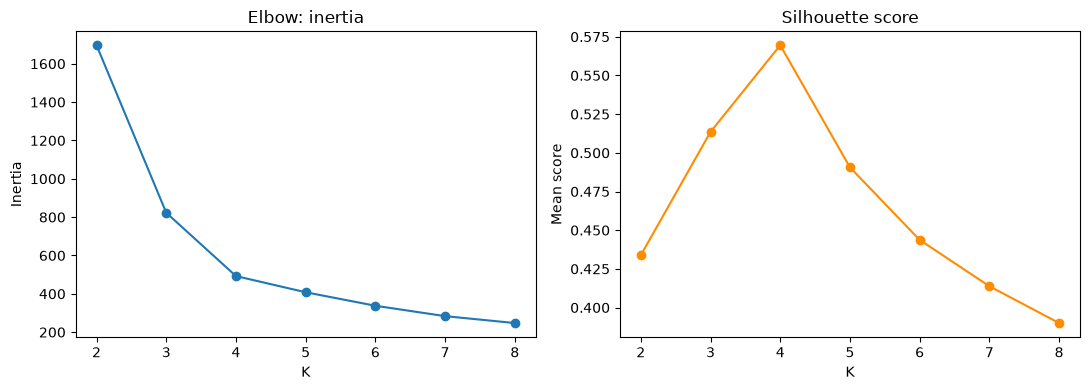

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4)) 
ax[0].plot(list(ks), inertia, marker="o"); ax[0].set_title("Elbow: inertia") 
ax[0].set_xlabel("K"); ax[0].set_ylabel("Inertia") 
ax[1].plot(list(ks), silhouette, marker="o", color="darkorange") 
ax[1].set_title("Silhouette score"); ax[1].set_xlabel("K"); ax[1].set_ylabel("Mean score") 
plt.tight_layout(); plt.show()

# Choose after reviewing the plots and business constraints 

In [10]:
best_k = list(ks)[int(np.argmax(silhouette))] 
model = models[best_k] 

# Assigning the cluster to each points 
rfm["Cluster"] = model.labels_ 

 # Profile in original units; cluster IDs are arbitrary 

In [11]:
profile = rfm.groupby("Cluster").agg( 
    Customers=("Cluster", "size"), 
    Recency=("Recency", "mean"), 
    Frequency=("Frequency", "mean"), 
    Monetary=("Monetary", "mean") 
) 
profile["Share_%"] = 100 * profile["Customers"] / len(rfm) 
print(profile.sort_values("Monetary", ascending=False).round(2)) 

         Customers  Recency  Frequency  Monetary  Share_%
Cluster                                                  
1              257    12.33      27.51   4517.30    21.42
2              199   251.33      15.26   2612.19    16.58
3              374    49.97      13.54   1855.29    31.17
0              370   126.35       4.35    714.18    30.83


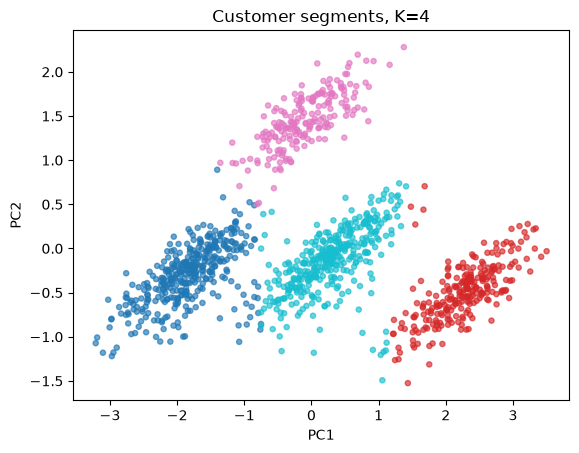

In [13]:
# Visualize with PCA only for visualization
coords = PCA(n_components=2, random_state=42).fit_transform(X_scaled) 
plt.scatter(coords[:, 0], coords[:, 1], c=rfm["Cluster"], cmap="tab10", s=14, alpha=.65) 
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"Customer segments, K={best_k}") 
plt.show() 

In [14]:
coords

array([[ 1.90241156, -0.64354003],
       [ 2.0336177 , -0.86410351],
       [ 2.5407164 , -0.15194904],
       ...,
       [-0.32460929,  1.27430888],
       [-1.40262318,  0.89098042],
       [-0.02493253,  1.43481148]], shape=(1200, 2))